# Procesamiento de Imágenes
## Sesión práctica 4
Profesor: Cristóbal Loyola<br>
Ayudante: Clemente Aguilar<br>
<br>Universidad de Santiago de Chile, 2025

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, color
from skimage.exposure import rescale_intensity
from skimage.util import img_as_ubyte
from skimage.color import rgb2gray
from skimage import exposure
from skimage.io import imread
from skimage.filters import threshold_otsu
import os

In [ ]:
def compute_histogram(img, normalize=False):
    hist, bins = np.histogram(img.flatten(), bins=256, range=[0,1])
    if normalize:
        hist = hist / hist.sum()
    return hist

def cumulative_histogram(img):
    hist = compute_histogram(img, normalize=True)
    cdf = np.cumsum(hist)
    return cdf

def show_histograms(img):
    # Muestra ambos histogramas: normal y acumulado
    hist = compute_histogram(img)
    cdf = cumulative_histogram(img)

    bins = range(256)

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.plot(bins, hist, color='blue')
    plt.title("Histograma")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(bins, cdf, color='red')
    plt.title("Histograma acumulado")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def show_image(images, h=1, w=1, cmap='gray'):
    # Hay que entregar images en formato de lista [imagen1, imagen2, ..., imagenN]
    # aunque sea solo 1 imagen
    figsize = (w * 6, h * 3)
    fig, axes = plt.subplots(h, w, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for idx, ax in enumerate(axes):
        ax.imshow(images[idx], cmap=cmap if images[idx].ndim == 2 else None)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

def binarize_otsu(img):
    thresh = threshold_otsu(img)
    return img > thresh

In [ ]:
# Ejemplo de tratamiento de imagen con más de 3 canales.
img = data.lily()
print(img.shape)
rgb_img = img[:, :, :3]
print(f"Valor mínimo: {np.min(rgb_img)}")
print(f"Valor máximo: {np.max(rgb_img)}")

rgb_scaled = (rgb_img / np.max(rgb_img)) * 255
rgb_uint8 = rgb_scaled.astype(np.uint8)

#show_image(rgb_uint8)

(922, 922, 4)
Valor mínimo: 0
Valor máximo: 4095


## Cargar la imagen de esta sesión
Para esta sesión se utilizará la imagen `rocket` desde Scikit-Image.<br>
Si lo deseas, se disponen bloques para que puedas cargar tu propia imagen independientemente del entorno de trabajo que utilices.

(427, 640, 3)


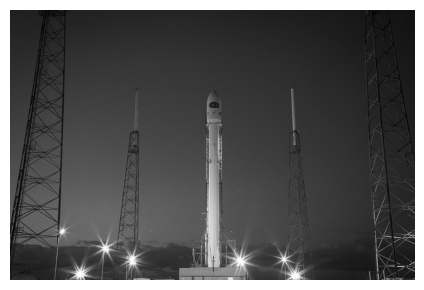

In [ ]:
# Imagen a utilizar en la sesión. Siéntanse en total libertad de cargar sus
# propias imágenes para esta experiencia utilizando imágenes públicas o
img = data.rocket()
print(img.shape)

# 1. Si estás trabajando en Google Colab y tienes tu imagen en Drive
"""
from google.colab import drive
drive.mount('/content/drive')

path = "ruta/a/tu/imagen.jpg"
img = imread(path)

# Asegurarse de estar trabajando sobre una imagen con 3 canales RGB usando
# img.shape y su tratamiento posterior necesario
"""

# 2. Si estás trabajando en un entorno local (no Google Colab o Jupyter Notebook)
"""
# Cargar imagen desde una ruta local
path = "ruta/a/tu/imagen.jpg"
img = imread(path)

# Asegurarse de estar trabajando sobre una imagen con 3 canales RGB usando
# img.shape y su tratamiento posterior necesario
"""

# 3. Si deseas trabajar sobre una imagen encontrada en la web
"""
url = "https://www.url/de/tu/imagen.jpg"
img = imread(url)

# Asegurarse de estar trabajando sobre una imagen con 3 canales RGB usando
# img.shape y su tratamiento posterior necesario
"""

gray_img = rgb2gray(img)
show_image([gray_img])

## Mejoramiento del contraste
- Corrección gamma
- Escalamiento lineal (Contrast Stretching)
- Ecualización de histograma
- Ecualización adaptativa

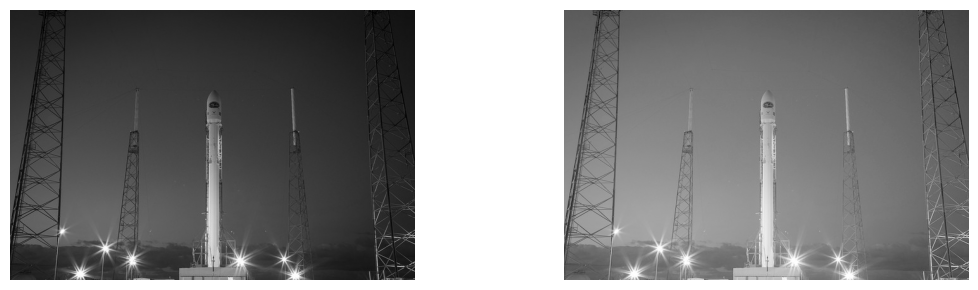

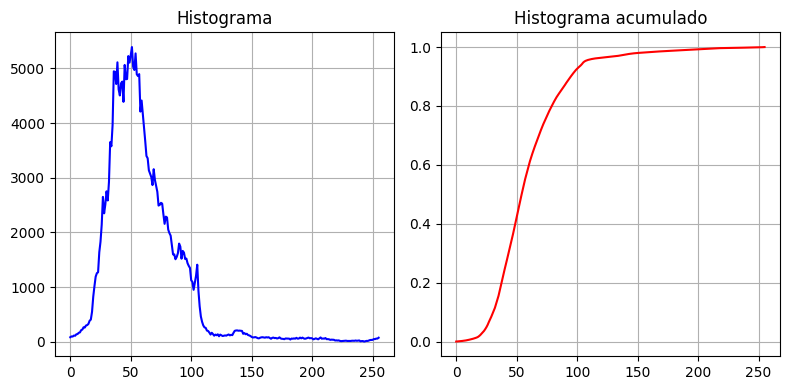

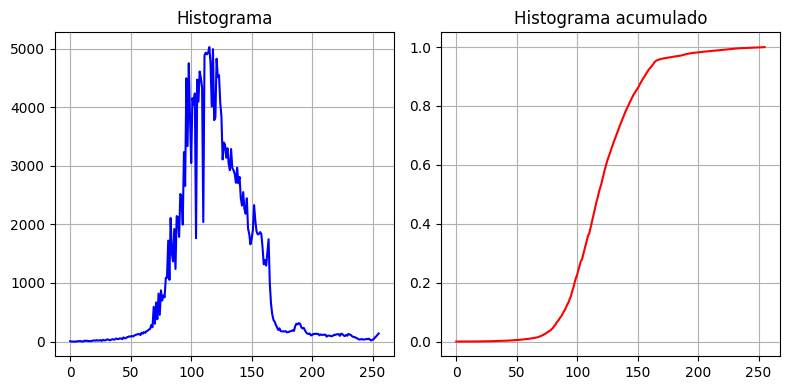

In [ ]:
# Corrección gamma
def gamma_correction(img, gamma):
    img_float = img_as_float(img)
    corrected = np.power(img_float, gamma)
    return corrected

# Cambiar gamma!
gamma_img = gamma_correction(gray_img, 0.5)

show_image([gray_img, gamma_img], 1, 2)

show_histograms(gray_img)
show_histograms(gamma_img)

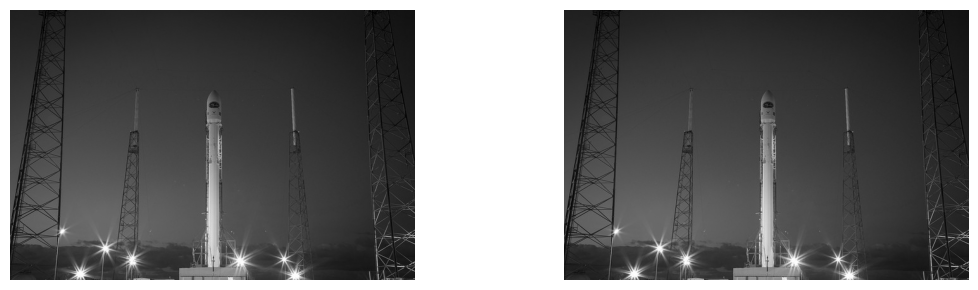

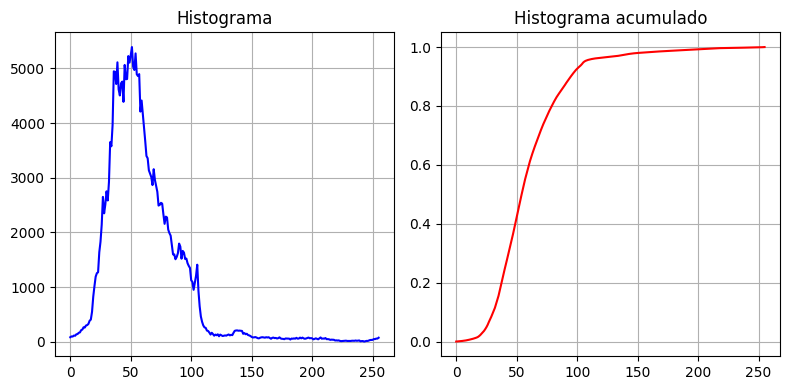

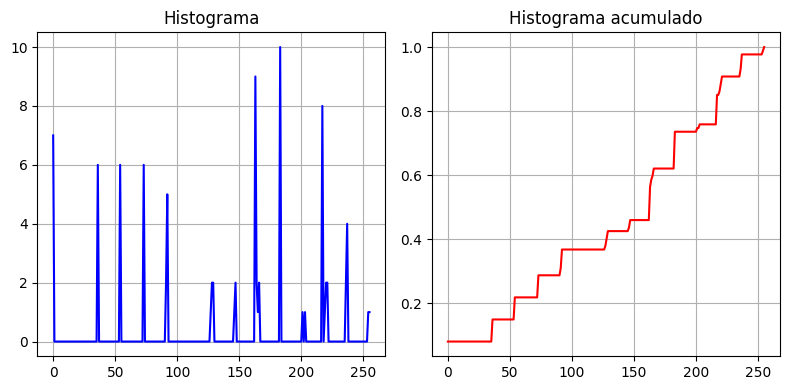

In [ ]:
# Contrast stretching
def contrast_stretching(img):
    a = np.min(img)
    b = np.max(img)
    stretched = ((img - a) / (b - a)) * 255
    return stretched

stretched_img = contrast_stretching(gray_img)

show_image([gray_img, stretched_img], 1, 2)

show_histograms(gray_img)
show_histograms(stretched_img)

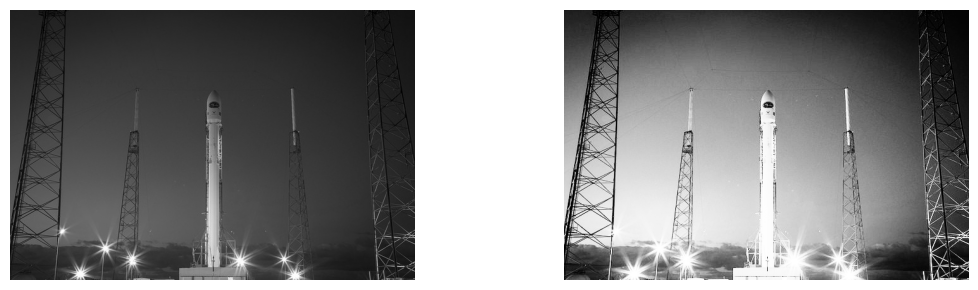

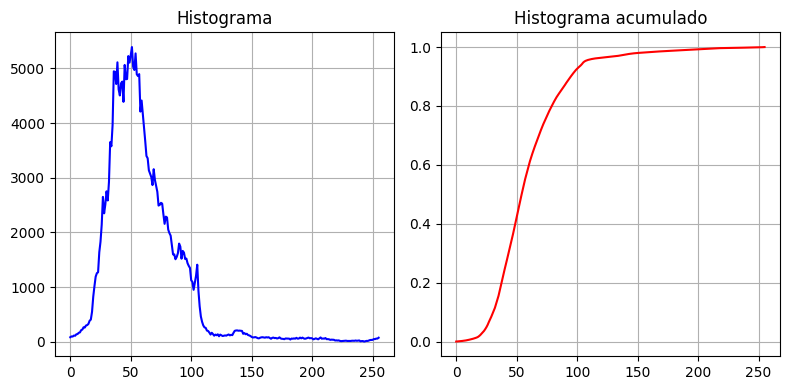

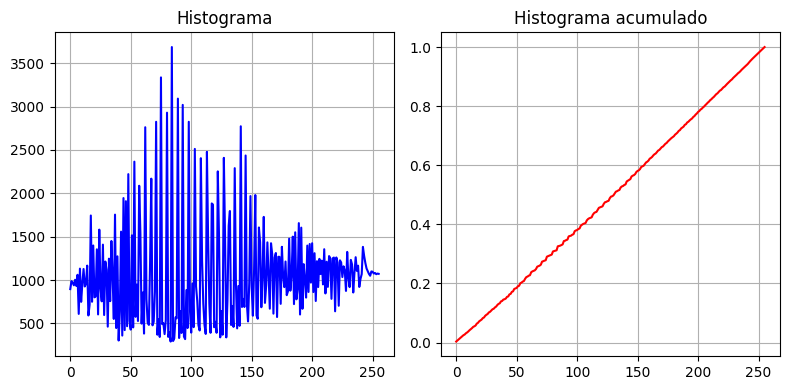

In [ ]:
# Ecualización de histograma
def histogram_equalization(img):
    # Recordar que el método que definimos cumulative_histogram está NORMALIZANDO
    cdf = cumulative_histogram(img)
    img_flat = img.flatten()

    equalized = np.interp(img_flat, np.linspace(0, 1, 256), cdf)

    return equalized.reshape(img.shape)

equalized_img = histogram_equalization(gray_img)

show_image([gray_img, equalized_img], 1, 2)

show_histograms(gray_img)
show_histograms(equalized_img)

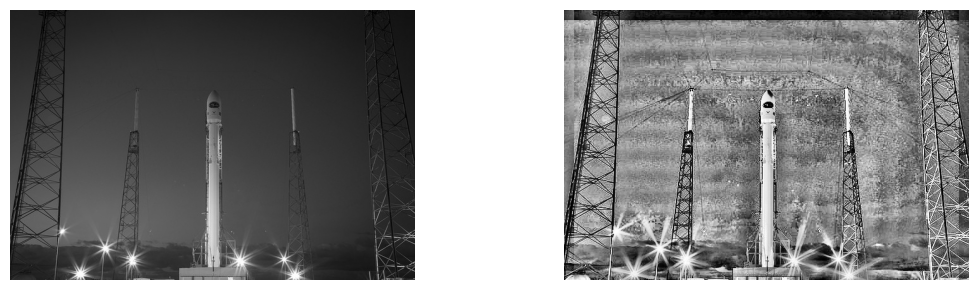

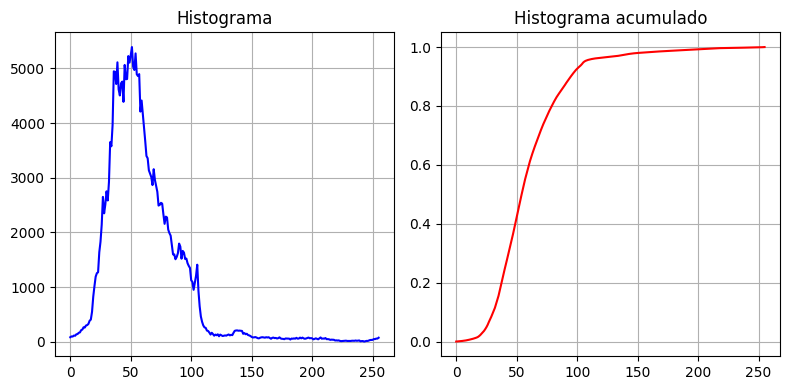

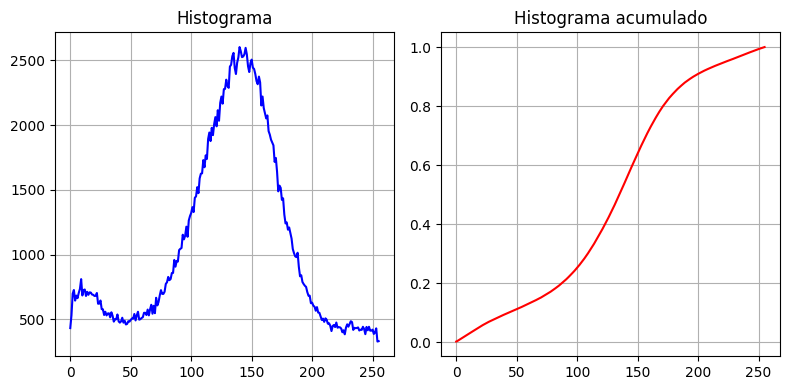

In [ ]:
def adaptive_hist_eq(img, tile_size=8):
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min())  # Normalizar a [0, 1]
    h, w = img.shape
    bins = 256

    # Dimensiones de la grilla
    n_tiles_y = int(np.ceil(h / tile_size))
    n_tiles_x = int(np.ceil(w / tile_size))

    # Precomputar los CDFs para cada tile
    cdfs = np.zeros((n_tiles_y, n_tiles_x, bins))
    for i in range(n_tiles_y):
        for j in range(n_tiles_x):
            y0 = i * tile_size
            x0 = j * tile_size
            y1 = min((i + 1) * tile_size, h)
            x1 = min((j + 1) * tile_size, w)
            tile = img[y0:y1, x0:x1]
            cdfs[i, j] = cumulative_histogram(tile)

    # Imagen de salida
    out = np.zeros_like(img)

    for y in range(h):
        for x in range(w):
            # Posición relativa en la grilla
            gx = x / tile_size - 0.5
            gy = y / tile_size - 0.5
            i = int(np.floor(gy))
            j = int(np.floor(gx))

            dy = gy - i
            dx = gx - j

            # Clip para no salir de los límites
            i = np.clip(i, 0, n_tiles_y - 2)
            j = np.clip(j, 0, n_tiles_x - 2)

            # Obtener los 4 CDFs vecinos
            cdf_tl = cdfs[i    , j    ]
            cdf_tr = cdfs[i    , j + 1]
            cdf_bl = cdfs[i + 1, j    ]
            cdf_br = cdfs[i + 1, j + 1]

            # Índice del bin del píxel actual
            pixel_val = img[y, x]
            bin_idx = int(pixel_val * (bins - 1))

            # Interpolación bilineal
            top = (1 - dx) * cdf_tl[bin_idx] + dx * cdf_tr[bin_idx]
            bottom = (1 - dx) * cdf_bl[bin_idx] + dx * cdf_br[bin_idx]
            new_val = (1 - dy) * top + dy * bottom

            out[y, x] = new_val

    return out

adap_equalized_img = adaptive_hist_eq(gray_img, 32)

show_image([gray_img, adap_equalized_img], 1, 2)

show_histograms(gray_img)
show_histograms(adap_equalized_img)

## Morfología matemática
- Dilatación
- Erosión
- Apertura
- Clausura
- Extracción de bordes

In [52]:
def dilate(img_bin, selem):
    pad = selem.shape[0] // 2
    padded = np.pad(img_bin, pad_width=pad, mode='constant', constant_values=0)
    result = np.zeros_like(img_bin)

    for i in range(result.shape[0]):
        for j in range(result.shape[1]):
            region = padded[i:i + selem.shape[0], j:j + selem.shape[1]]
            result[i, j] = np.any(region & selem)

    return result

def erode(img_bin, selem):
    pad = selem.shape[0] // 2
    padded = np.pad(img_bin, pad_width=pad, mode='constant', constant_values=0)
    result = np.zeros_like(img_bin)

    for i in range(result.shape[0]):
        for j in range(result.shape[1]):
            region = padded[i:i + selem.shape[0], j:j + selem.shape[1]]
            result[i, j] = np.all(region[selem == 1])

    return result

def opening(img_bin, selem):
    return dilate(erode(img_bin, selem), selem)

def closing(img_bin, selem):
    return erode(dilate(img_bin, selem), selem)

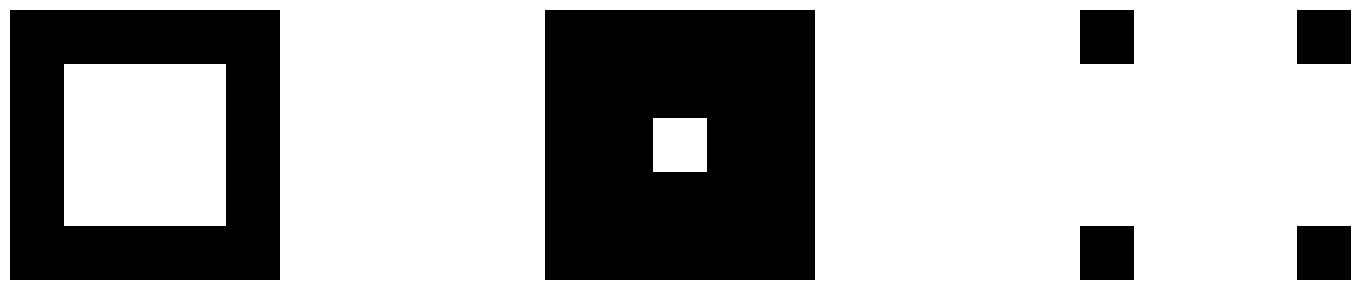

In [57]:
# Se define una imagen binaria de 5x5 con el centro 3x3 de la imagen siendo 1
# y el resto 0
img = np.zeros((5, 5), dtype=np.uint8)
img[1:4, 1:4] = 1

# Ahora se define un elemento estructural 3x3 con una cruz de 1 en el centro
se = np.array([[0, 1, 0],
               [1, 1, 1],
               [0, 1, 0]], dtype=np.uint8)
# Aplicar erosión y dilatación, mostrar resultados
eroded = erode(img, se)
dilated = dilate(img, se)

show_image([img, eroded, dilated], 1, 3)


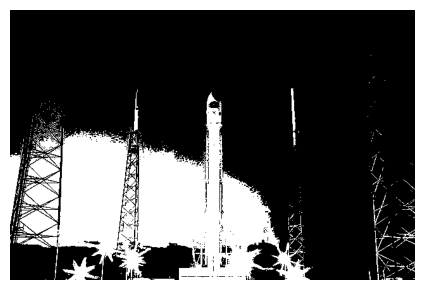

In [ ]:
# Imágen binarizada
image_bin = binarize_otsu(gray_img)
#img_bin_neg = 255 - image_bin
show_image([image_bin])

In [ ]:
# Definición de un elemento estructural 'selem' con forma
"""
[1, 1, 1]
[1, 1, 1]
[1, 1, 1]
"""
# Distintos elementos estructurales llevan a distintos resultados
se = np.ones((3, 3), dtype=np.uint8)

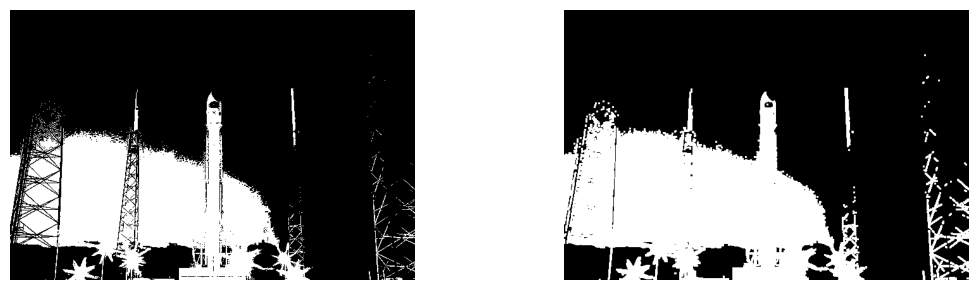

In [ ]:
dilated_img = dilate(image_bin, se)
show_image([image_bin, dilated_img], 1, 2)

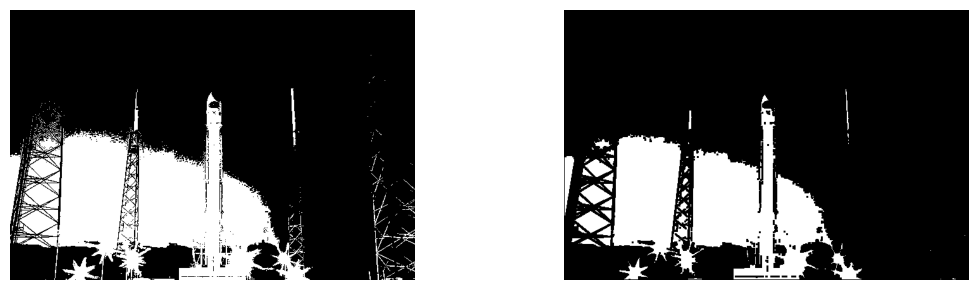

In [ ]:
eroded_img = erode(image_bin, se)
show_image([image_bin, eroded_img], 1, 2)

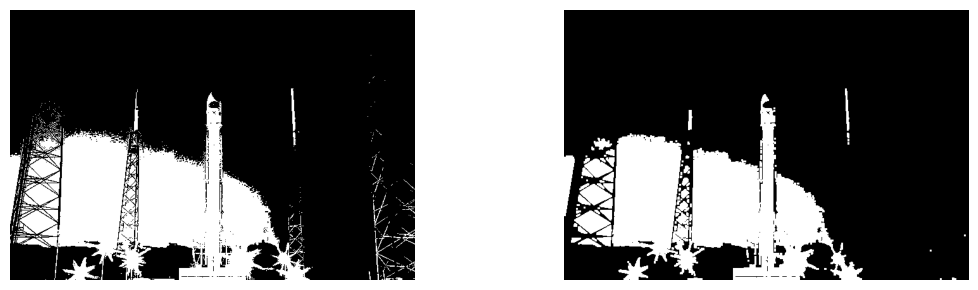

In [ ]:
opened_img = opening(image_bin, se)
show_image([image_bin, opened_img], 1, 2)

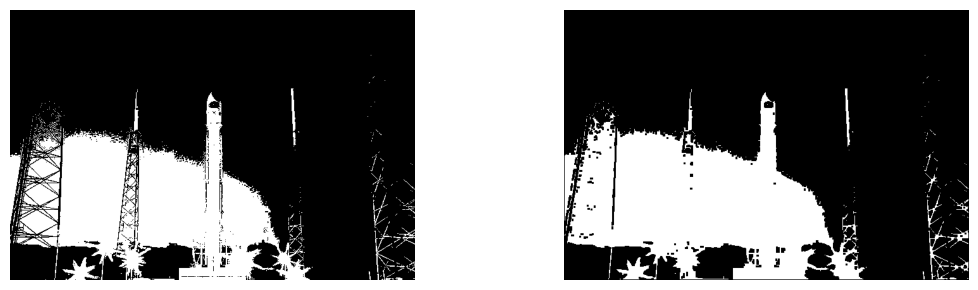

In [ ]:
closed_img = closing(image_bin, se)
show_image([image_bin, closed_img], 1, 2)

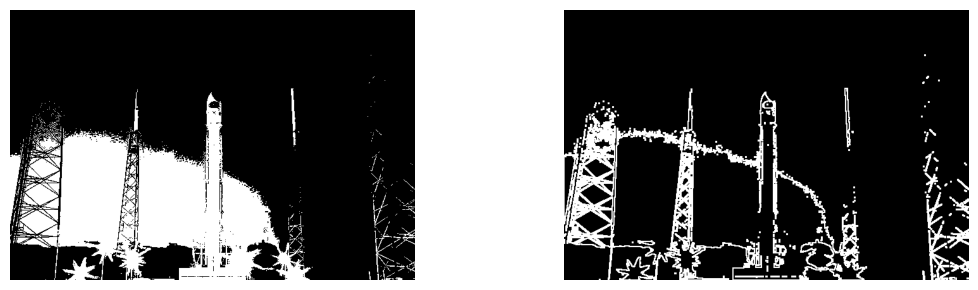

In [ ]:
def extract_edges(img_bin, selem):
    dil = dilate(img_bin, selem)
    ero = erode(img_bin, selem)
    return np.bitwise_xor(dil, ero)

edges_img = extract_edges(image_bin, se)
show_image([image_bin, edges_img], 1, 2)